# List 1

**Introduction to tools for data analysis and classification model building**

In the following tasks you will use the *Adult* dataset available in the `sklearn` library.

In [1]:
from sklearn.datasets import fetch_openml
adult = fetch_openml("adult", version=2, as_frame=True)
df = adult.frame
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In this version of the dataset, the target variable is the `class` column.
While completing the tasks, you should use the following libraries: `pandas`, `matplotlib`, `sklearn`, and `torch`.

---

## 1. EDA — pandas

The goal of this section is to become familiar with basic operations on a `DataFrame`.

### Task 1 — Basic information

1. Print the number of rows and columns in the dataset.
2. Print the names of all columns.
3. Check the number of missing values in each column.
4. Display descriptive statistics for numerical columns using the appropriate `pandas` method.

In [2]:
print(df.shape)
print(df.columns)

cnt_missing = df.isnull().sum()
print(cnt_missing)

# print(df.info())
print(df.describe())

(48842, 15)
Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'class'],
      dtype='object')
age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
class                0
dtype: int64
                age        fnlwgt  education-num  capital-gain  capital-loss  \
count  48842.000000  4.884200e+04   48842.000000  48842.000000  48842.000000   
mean      38.643585  1.896641e+05      10.078089   1079.067626     87.502314   
std       13.710510  1.056040e+05       2.570973   7452.019058    403.004552   
min       17.000000  1.228500e+04       1.000000      0.000

### Task 2 — Category counts

1. Compute the number of observations in each category of the `education` variable.
2. Sort the result in descending order by count.
3. Print the five most frequent categories.

In [3]:
cnt = df["education"].value_counts()
cnt.sort_values(ascending=False)
print(cnt.head(5))

education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
Name: count, dtype: int64


### Task 3 — Grouping and aggregation

For each category of the `education` variable, compute:

* the mean value of `hours-per-week`,
* the mean value of `capital-gain`,
* the percentage of observations belonging to the `>50K` class (based on the `class` column).

Use the `groupby()` and `agg()` methods.

In [4]:
import pandas as pd

grouped = df.groupby("education")

mean_hpw = grouped["hours-per-week"].mean()

mean_cg = grouped["capital-gain"].mean()

cnt_g50_class = grouped["class"].apply(lambda x: (x == ">50K").sum())
perc_g50_class = cnt_g50_class / grouped.size() * 100

result = pd.DataFrame({
    "mean hpw": mean_hpw,
    "mean cg": mean_cg,
    "perc >50K": perc_g50_class
})
print(result)

               mean hpw       mean cg  perc >50K
education                                       
10th          36.986321    323.049676   6.263499
11th          33.952539    203.739514   5.077263
12th          35.374429    208.579909   7.305936
1st-4th       38.761134    123.591093   3.238866
5th-6th       38.923379    360.365422   5.304519
7th-8th       39.003141    242.626178   6.492147
9th           38.359788    313.398148   5.423280
Assoc-acdm    40.809494    636.951905  25.796377
Assoc-voc     41.658418    778.602135  25.327511
Bachelors     42.482492   1762.564984  41.283489
Doctorate     46.582492   5727.769360  72.558923
HS-grad       40.640775    573.314179  15.857831
Masters       43.575837   2583.605947  54.911554
Preschool     36.566265    732.000000   1.204819
Prof-school   47.579137  10586.467626  73.980815
Some-college  38.865784    559.961574  18.964883


/tmp/ipykernel_906/303120957.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("education")


### Task 4 — Filtering data

1. Select observations for which `capital-gain > 0`.
2. Compute the mean `hours-per-week` for this group.
3. Compute the mean `hours-per-week` for observations with `capital-gain == 0`.

In [5]:
print(df[df["capital-gain"] != 0]["hours-per-week"].mean())
print(df[df["capital-gain"] == 0]["hours-per-week"].mean())

43.52614622057001
40.14287946079853


### Task 5 — Creating a new column

1. Create a new column called `hours_bucket` by dividing `hours-per-week` into intervals of 10 hours using `pd.cut`.
2. Compute the number of observations in each interval.
3. Create a pivot table in which:

   * the index is `hours_bucket`,
   * the columns correspond to `class`,
   * the values represent the number of observations.

In [6]:
df['hours_bucket'] = pd.cut(df['hours-per-week'], bins=range(0, 100, 10))

print(df['hours_bucket'].value_counts())

pivot_table = pd.pivot_table(df, index='hours_bucket', columns='class', values='age', aggfunc='count')
print(pivot_table)

hours_bucket
(30, 40]    26639
(40, 50]     8917
(50, 60]     3759
(20, 30]     3398
(10, 20]     3328
(0, 10]      1125
(60, 70]      902
(70, 80]      456
(80, 90]      147
Name: count, dtype: int64
class         <=50K  >50K
hours_bucket             
(0, 10]        1020   105
(10, 20]       3132   196
(20, 30]       3173   225
(30, 40]      21220  5419
(40, 50]       5398  3519
(50, 60]       2135  1624
(60, 70]        570   332
(70, 80]        289   167
(80, 90]         95    52


/tmp/ipykernel_906/2689043825.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = pd.pivot_table(df, index='hours_bucket', columns='class', values='age', aggfunc='count')


## 2. Visualization — matplotlib

Each plot must include a title, axis labels, and a legend (if applicable).

---

### Plot 1 — Histogram

Create a histogram of the `hours-per-week` variable.
Choose the number of bins in a reasonable way.

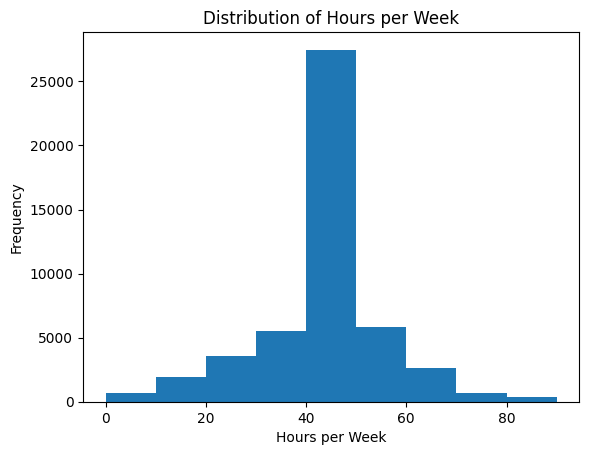

In [7]:
import matplotlib.pyplot as plt

plt.hist(df['hours-per-week'], bins=range(0, 100, 10))
plt.xlabel('Hours per Week')
plt.ylabel('Frequency')
plt.title('Distribution of Hours per Week')
plt.show()


### Plot 2 — Histogram comparison

On a single figure, plot two histograms of `hours-per-week`:

* one for the `<=50K` class,
* one for the `>50K` class.

The histograms should be semi-transparent (set the `alpha` parameter).

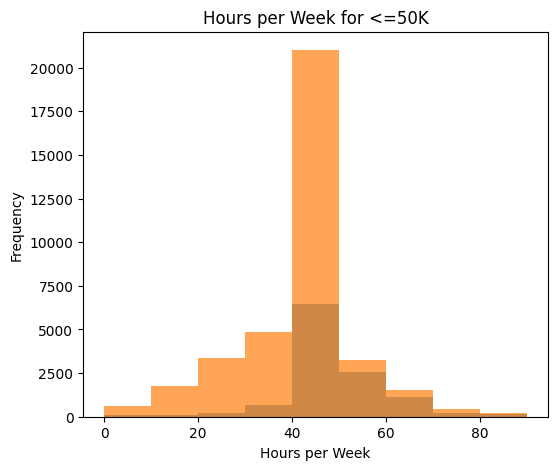

In [27]:
# fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# ax[0].hist(df[df['class'] == '>50K']['hours-per-week'], bins=range(0, 100, 10), alpha=0.7)
# ax[0].set_title('Hours per Week for >50K')
# ax[0].set_xlabel('Hours per Week')
# ax[0].set_ylabel('Frequency')

# ax[1].hist(df[df['class'] == '<=50K']['hours-per-week'], bins=range(0, 100, 10), alpha=0.7)
# ax[1].set_title('Hours per Week for <=50K')
# ax[1].set_xlabel('Hours per Week')
# ax[1].set_ylabel('Frequency')

# plt.show()

fig, ax = plt.subplots(1, 1, figsize=(6, 5))

ax.hist(df[df['class'] == '>50K']['hours-per-week'], bins=range(0, 100, 10), alpha=0.7)
ax.set_title('Hours per Week for >50K')
ax.set_xlabel('Hours per Week')
ax.set_ylabel('Frequency')

ax.hist(df[df['class'] == '<=50K']['hours-per-week'], bins=range(0, 100, 10), alpha=0.7)
ax.set_title('Hours per Week for <=50K')
ax.set_xlabel('Hours per Week')
ax.set_ylabel('Frequency')

plt.show()

### Plot 3 — Bar chart

Create a bar chart showing the number of observations for each category of the `education` variable.

/tmp/ipykernel_906/1257944592.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  edu_cnt = df.groupby('education').count()['age']


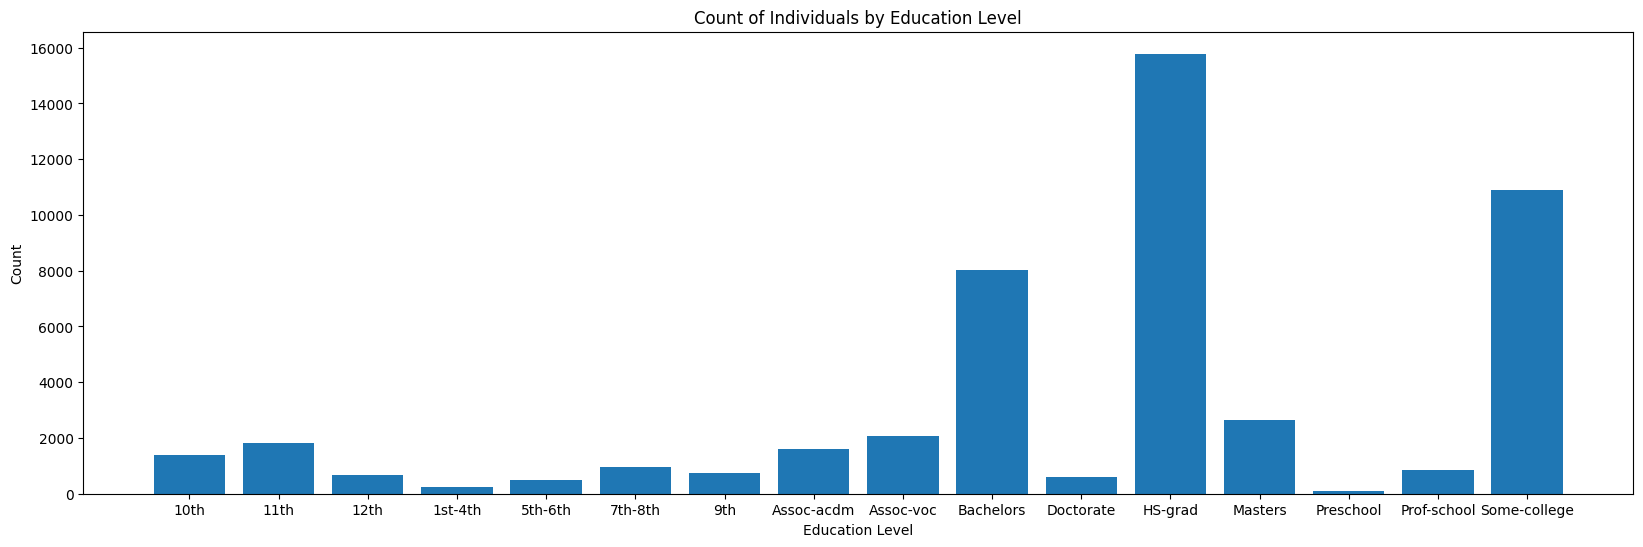

In [9]:
edu_cnt = df.groupby('education').count()['age']

plt.figure(figsize=(20, 6))
plt.bar(edu_cnt.index, edu_cnt.values)
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.title('Count of Individuals by Education Level')
plt.show()

### Plot 4 — Scatter plot

Create a scatter plot where:

* the X-axis represents `capital-gain`,
* the Y-axis represents `hours-per-week`.

Set `alpha < 0.3`.

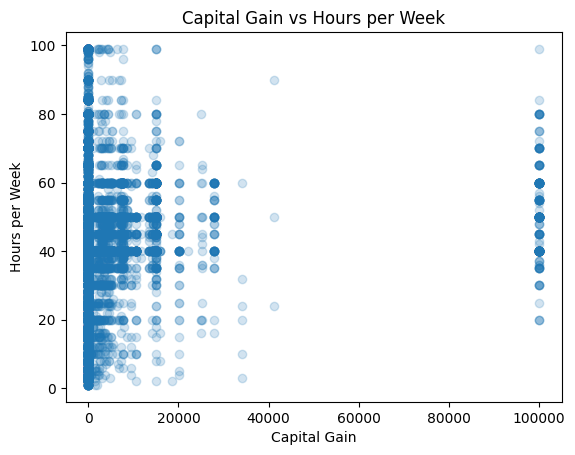

In [10]:
plt.scatter(df['capital-gain'], df['hours-per-week'], alpha=0.2)
plt.xlabel('Capital Gain')
plt.ylabel('Hours per Week')
plt.title('Capital Gain vs Hours per Week')
plt.show()

### Plot 5 — Logarithmic scale

Create a histogram of `capital-gain`.
Set the X-axis to a logarithmic scale.

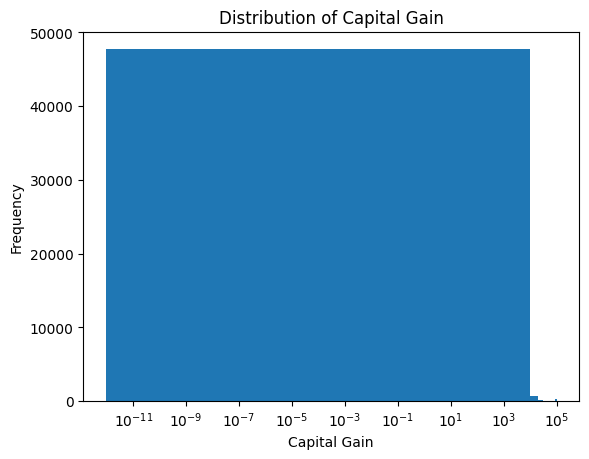

In [11]:
plt.hist(df['capital-gain'])
plt.xscale('log')
plt.xlabel('Capital Gain')
plt.ylabel('Frequency')
plt.title('Distribution of Capital Gain')
plt.show()

## 3. Data splitting — sklearn

Before splitting the data, separate:

* the feature matrix `X` (all columns except `class`),
* the target vector `y` (the `class` column).

In [12]:
X = df.drop(columns=['class'])
y = (df['class'] == '>50K').astype(int)

### Task 1 — Train/validation/test split

1. Split the data into:

   * training set (60%),
   * validation set (20%),
   * test set (20%).

2. Use `train_test_split` with the `stratify=y` parameter to preserve class proportions.

3. Print the size of each split.

4. Print the class proportions in each split.

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25, stratify=y_train
)

print(X_train.shape, X_val.shape, X_test.shape)

print("train", y_train.value_counts(normalize=True))
print("Val", y_val.value_counts(normalize=True))
print("Test", y_test.value_counts(normalize=True))

(29304, 15) (9769, 15) (9769, 15)
train class
0    0.760715
1    0.239285
Name: proportion, dtype: float64
Val class
0    0.760774
1    0.239226
Name: proportion, dtype: float64
Test class
0    0.760672
1    0.239328
Name: proportion, dtype: float64


### Task 2 — Baseline model

The baseline model is a classifier that does not use input features and always predicts the majority class from the training set.

1. Determine the majority class in the training set.
2. Build a classifier that predicts this class for all test observations.
3. Compute the following metrics on the test set:

   * Accuracy,
   * Precision,
   * Recall,
   * F1.

You may implement this manually or use `DummyClassifier(strategy="most_frequent")`.

In [14]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_train, y_train)

y_test_pred = dummy_clf.predict(X_test)

acc = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred, zero_division=0)
recall = recall_score(y_test, y_test_pred, zero_division=0)
f1 = f1_score(y_test, y_test_pred, zero_division=0)

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.7607
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000


## 4. Pipeline — sklearn

### Task 1 — Preprocessing

1. Split the columns into numerical and categorical features.

2. Build a `ColumnTransformer` where:

   * numerical columns are processed with:

     * `SimpleImputer(strategy="median")`,
     * `StandardScaler`,
   * categorical columns are processed with:

     * `SimpleImputer(strategy="most_frequent")`,
     * `OneHotEncoder(handle_unknown="ignore")`.

3. Fit the preprocessing pipeline on the training set and check the shape of the transformed feature matrix.

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

num_cols = X_train.select_dtypes(include='number').columns
print(num_cols)

cat_cols = X_train.select_dtypes(exclude='number').columns
print(cat_cols)

ct = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_cols)
])

X_train_transformed = ct.fit_transform(X_train)
print(X_train_transformed.shape)

Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')
Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'hours_bucket'],
      dtype='object')
(29304, 114)


### Task 2 — Logistic regression

1. Build a `Pipeline` consisting of:

   * preprocessing,
   * `LogisticRegression(max_iter=1000)`.

2. Train the model on the training set.

3. Compute the following metrics on the validation set:

   * Accuracy,
   * F1,

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

pipeline = Pipeline([
    ('preprocessor', ct),
    ('classifier', LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)

y_val_pred = pipeline.predict(X_val)

val_accuracy = accuracy_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred, zero_division=0)

print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Validation F1 Score: {val_f1:.4f}")

Validation Accuracy: 0.8558
Validation F1 Score: 0.6654


## 5. GridSearch

### Task — Hyperparameter tuning for logistic regression

1. Define the parameter grid:

   * `C`: [0.01, 0.1, 1, 10].

2. Use `GridSearchCV` with:

   * `scoring="f1"`,
   * `cv=5`.

3. Fit the model on the training set.

4. Print the best parameters (`best_params_`) and the best cross-validation score (`best_score_`).

In [17]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10]
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
 )

grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation F1 score: {grid_search.best_score_:.4f}")

Best parameters: {'classifier__C': 10}
Best cross-validation F1 score: 0.6609


## 6. MLP — PyTorch

In this section, use the data after preprocessing (the same transformations as in `sklearn`).

1. Fit the preprocessing pipeline on the training set.
2. Transform the training, validation, and test sets.
3. Convert the resulting matrices to `float32` tensors.
4. Encode the labels as 0 and 1.

---

### Task 1 — Network architecture

Build an MLP with the following structure:

* Input layer: number of neurons equal to the number of features after preprocessing.
* Hidden layer 1: `Linear(in_features, 128)` → `ReLU` → `Dropout(p=0.3)`.
* Hidden layer 2: `Linear(128, 64)` → `ReLU` → `Dropout(p=0.3)`.
* Hidden layer 3: `Linear(64, 32)` → `ReLU` → `Dropout(p=0.3)`.
* Output layer: `Linear(32, 1)`.

Do not apply a sigmoid activation inside the model.
Use `BCEWithLogitsLoss` as the loss function.

In [18]:
import copy
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

ct.fit(X_train)
X_train_pre = ct.transform(X_train)
X_val_pre = ct.transform(X_val)
X_test_pre = ct.transform(X_test)

X_train_np = X_train_pre.toarray()
X_val_np = X_val_pre.toarray()
X_test_np = X_test_pre.toarray()

X_train_tensor = torch.tensor(X_train_np, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_np, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_np, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values.astype(np.float32), dtype=torch.float32).unsqueeze(1)
y_val_tensor = torch.tensor(y_val.values.astype(np.float32), dtype=torch.float32).unsqueeze(1)
y_test_tensor = torch.tensor(y_test.values.astype(np.float32), dtype=torch.float32).unsqueeze(1)


In [19]:
class MLPClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.net(x)

input_dim = X_train_tensor.shape[1]
mlp_model = MLPClassifier(input_dim)
criterion = nn.BCEWithLogitsLoss()

print(f"Input dimension after preprocessing: {input_dim}")
print("MLP model initialized.")


Input dimension after preprocessing: 114
MLP model initialized.


### Task 2 — Training

1. Use the `Adam` optimizer.

2. Apply a `StepLR` scheduler with `step_size=5` and `gamma=0.5`.

3. Implement early stopping with `patience=5`, monitoring the validation loss.

4. During each epoch, record:

   * training loss,
   * validation loss,
   * validation accuracy.

5. After training, plot training loss and validation loss as a function of epoch number.

In [28]:
from sklearn.metrics import accuracy_score
from tqdm.auto import tqdm

optimizer = torch.optim.Adam(mlp_model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

num_epochs = 200
patience = 5
best_val_loss = float('inf')
epochs_no_improve = 0
best_state = None

train_losses = []
val_losses = []
val_accuracies = []

progress_bar = tqdm(range(1, num_epochs + 1), desc='Training MLP')
for epoch in progress_bar:
    mlp_model.train()
    optimizer.zero_grad()
    train_logits = mlp_model(X_train_tensor)
    train_loss = criterion(train_logits, y_train_tensor)
    train_loss.backward()
    optimizer.step()

    mlp_model.eval()
    with torch.no_grad():
        val_logits = mlp_model(X_val_tensor)
        val_loss = criterion(val_logits, y_val_tensor)
        val_probs = torch.sigmoid(val_logits)

    val_true = y_val_tensor
    val_pred = (val_probs >= 0.5)
    val_acc = accuracy_score(val_true, val_pred)

    train_losses.append(train_loss.item())
    val_losses.append(val_loss.item())
    val_accuracies.append(val_acc)

    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    progress_bar.set_postfix({
        'train_loss': f'{train_loss.item():.4f}',
        'val_loss': f'{val_loss.item():.4f}',
        'val_acc': f'{val_acc:.4f}',
        'wait': f'{epochs_no_improve}/{patience}'
    })
    # tqdm.write(f"Epoch {epoch:02d}: val_loss={val_loss.item():.4f}")

    scheduler.step()

    if epochs_no_improve >= patience:
        tqdm.write(f"Early stopping triggered after epoch {epoch}.")
        break

print(f"Final train loss: {train_losses[-1]:.4f}")
print(f"Best val loss: {best_val_loss:.4f}")
print(f"Final val accuracy: {val_accuracies[-1]:.4f}")

Training MLP:   0%|          | 0/200 [00:00<?, ?it/s]

Early stopping triggered after epoch 101.
Final train loss: 0.3680
Best val loss: 0.3603
Final val accuracy: 0.8369


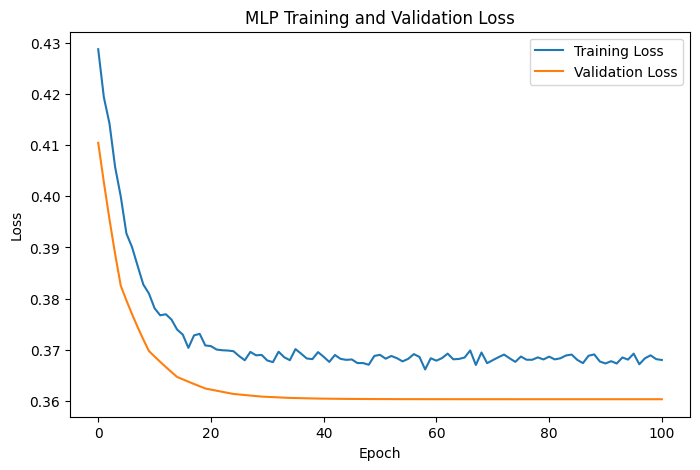

In [29]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('MLP Training and Validation Loss')
plt.legend()
plt.show()

### Task 3 — Evaluation

On the test set, compute:

* Accuracy,
* F1.

In [22]:
from sklearn.metrics import f1_score

mlp_model.eval()
with torch.no_grad():
    test_logits = mlp_model(X_test_tensor)
    test_probs = torch.sigmoid(test_logits).cpu().numpy().ravel()

mlp_test_pred = (test_probs >= 0.5).astype(int)
mlp_test_true = y_test_tensor.cpu().numpy().ravel().astype(int)

mlp_test_accuracy = accuracy_score(mlp_test_true, mlp_test_pred)
mlp_test_f1 = f1_score(mlp_test_true, mlp_test_pred, zero_division=0)

print(f"MLP Test Accuracy: {mlp_test_accuracy:.4f}")
print(f"MLP Test F1: {mlp_test_f1:.4f}")

MLP Test Accuracy: 0.7607
MLP Test F1: 0.0000


## 7. Error analysis

1. Compute predicted probabilities for the positive class on the test set.
2. Identify:

   * 50 false positive cases with the highest predicted probability,
   * 50 false negative cases with the highest predicted probability.

In [23]:
error_df = X_test.copy()
error_df['y_true'] = mlp_test_true
error_df['y_pred'] = mlp_test_pred
error_df['y_prob_pos'] = test_probs

false_positives = error_df[(error_df['y_true'] == 0) & (error_df['y_pred'] == 1)]
false_negatives = error_df[(error_df['y_true'] == 1) & (error_df['y_pred'] == 0)]

top_50_fp = false_positives.sort_values('y_prob_pos', ascending=False).head(50)
top_50_fn = false_negatives.sort_values('y_prob_pos', ascending=False).head(50)

print(f"False positives: {len(false_positives)}")
print(f"False negatives: {len(false_negatives)}")
print("\nTop 50 false positives:")
display(top_50_fp.head())
print("\nTop 50 false negatives:")
display(top_50_fn.head())

False positives: 0
False negatives: 2338

Top 50 false positives:


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,hours_bucket,y_true,y_pred,y_prob_pos



Top 50 false negatives:


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,hours_bucket,y_true,y_pred,y_prob_pos
19947,51,Private,255412,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,50,France,"(40, 50]",1,0,0.495938
34025,41,Private,150755,Doctorate,16,Married-civ-spouse,Exec-managerial,Husband,White,Male,15024,0,50,Canada,"(40, 50]",1,0,0.495192
32501,36,Private,175759,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,7298,0,50,United-States,"(40, 50]",1,0,0.492543
18864,41,Private,168071,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,7298,0,50,United-States,"(40, 50]",1,0,0.492508
13992,44,Private,172307,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,7688,0,50,United-States,"(40, 50]",1,0,0.492349


## 8. Final report

In the final report, answer the following questions:

1. Which model achieved the highest F1 score?
2. Do the learning curves indicate a stable training process?
3. Did overfitting occur in the MLP model (compare training and validation loss)?

**Which model achieved the highest F1 score?**  
Logistic regression with 0.66

**Do the learning curves indicate a stable training process?**  
MLP stable, dropouts help to prevent overfitting

**Did overfitting occur in the MLP model?**  
No
